<div style="
    border-left:5px solid #52746D;
    padding:10px 0 10px 20px;
    margin:18px 0 25px 0;
">

<p style="
    color:#5F7771;
    font-size:14px;
    font-weight:bold;
    letter-spacing:1.3px;
    margin:0 0 9px 0;
">
WEEK 6 · DEEP LEARNING · DAY 4
</p>

<h1 style="
    color:#294A46;
    font-size:31px;
    margin:0 0 9px 0;
">
Building & Training a Neural Network in Keras
</h1>

<p style="
    color:#64746F;
    font-size:16px;
    margin:0;
">
From architecture to training, diagnosis, regularization, and model comparison
</p>

</div>

<div style="
    background:#F0FDFA;
    border-left:5px solid #0F766E;
    border-radius:12px;
    padding:15px 18px;
    margin:17px 0;
">

<p style="color:#334155;line-height:1.8;margin:0;">
Today, I will build my first
<b style="color:#1D4ED8;">Keras Sequential Neural Network</b>
for heart-disease prediction.

I will train it using the same dataset and test set used by the
<b style="color:#BE123C;">Day 1 baseline</b>,
then inspect the learning curves, reduce overfitting using
<b style="color:#7C3AED;">Batch Normalization and Dropout</b>,
and compare the final results fairly.
</p>

</div>

<div style="
    background:#FFFFFF;
    border:1px solid #CBD5E1;
    border-radius:15px;
    padding:18px 20px;
    margin:18px 0;
">

<p style="color:#0F766E;font-weight:bold;letter-spacing:1px;margin:0 0 8px 0;">
EXPERIMENT BLUEPRINT
</p>

<h2 style="color:#0F172A;margin:0 0 14px 0;">
What Stays Fixed, and What Changes?
</h2>

<table style="width:100%;border-collapse:collapse;color:#334155;line-height:1.7;">
<tr style="background:#F8FAFC;">
<td style="padding:10px;border:1px solid #E2E8F0;"><b>Dataset</b></td>
<td style="padding:10px;border:1px solid #E2E8F0;">918 records · 21 processed inputs</td>
</tr>
<tr>
<td style="padding:10px;border:1px solid #E2E8F0;"><b>Fixed controls</b></td>
<td style="padding:10px;border:1px solid #E2E8F0;">Same split, preprocessing, architecture size, Adam, learning rate, epochs, and batch size</td>
</tr>
<tr style="background:#F8FAFC;">
<td style="padding:10px;border:1px solid #E2E8F0;"><b>Experimental change</b></td>
<td style="padding:10px;border:1px solid #E2E8F0;">Add Batch Normalization and 30% Dropout</td>
</tr>
<tr>
<td style="padding:10px;border:1px solid #E2E8F0;"><b>Reference to beat</b></td>
<td style="padding:10px;border:1px solid #E2E8F0;">Day 1 Logistic Regression · F1 = 0.899</td>
</tr>
</table>

<p style="color:#475569;line-height:1.8;margin:13px 0 0 0;">
This controlled design makes the comparison meaningful: if performance changes,
the main explanation is the regularization strategy rather than a different dataset or test split.
</p>

</div>

<div style="
    background:linear-gradient(135deg,#312E81 0%,#6D28D9 58%,#BE185D 100%);
    border-radius:16px;
    padding:22px 24px;
    margin:24px 0 16px 0;
">

<p style="color:#FBCFE8;font-weight:bold;letter-spacing:1.3px;margin:0 0 8px 0;">
LESSON FIRST · BEFORE THE HANDS-ON
</p>

<h2 style="color:#FFFFFF;margin:0 0 9px 0;">
How Does Keras Turn an Architecture into a Trained Model?
</h2>

<p style="color:#EDE9FE;line-height:1.8;margin:0;">
Before writing the network, I will connect today's framework to the training loop from Day 3:
build the layers, define how errors are measured, train the parameters, inspect the history,
and evaluate once on unseen data.
</p>

</div>

<div style="
    background:#EFF6FF;
    border-left:5px solid #2563EB;
    border-radius:12px;
    padding:16px 19px;
    margin:16px 0;
">

<p style="color:#2563EB;font-weight:bold;letter-spacing:1px;margin:0 0 7px 0;">
LESSON 4.1
</p>

<h2 style="color:#1E3A8A;margin:0 0 9px 0;">
TensorFlow and Keras
</h2>

<p style="color:#475569;line-height:1.85;margin:0;">
<b style="color:#7C3AED;">TensorFlow</b>
is the computation engine that handles tensors, gradients, backpropagation, and parameter updates.
<b style="color:#DB2777;">Keras</b>
is its high-level interface: I describe the model layer by layer, while the framework performs the
underlying matrix operations automatically.

<br><br>

The relationship is similar to an engine and its control panel:
Keras gives me a clearer way to control the TensorFlow engine without manually implementing every derivative.
</p>

</div>

<div style="
    background:#ECFDF5;
    border-left:5px solid #10B981;
    border-radius:12px;
    padding:16px 19px;
    margin:16px 0;
">

<p style="color:#059669;font-weight:bold;letter-spacing:1px;margin:0 0 7px 0;">
LESSON 4.2
</p>

<h2 style="color:#047857;margin:0 0 9px 0;">
Sequential Models and Dense Layers
</h2>

<p style="color:#475569;line-height:1.85;margin:0;">
The <b style="color:#2563EB;">Sequential API</b> creates a straight stack:
the output of one layer becomes the input of the next.
A <b style="color:#DB2777;">Dense layer</b> is fully connected, meaning every neuron receives
all outputs from the previous layer.
</p>

<div style="
    background:#0F172A;
    border-radius:11px;
    padding:14px;
    margin:13px 0;
    text-align:center;
">
<p style="color:#FFFFFF;font-size:17px;font-weight:bold;margin:0;">
Layer Output = Activation(Inputs × Weights + Bias)
</p>
</div>

<p style="color:#475569;line-height:1.85;margin:0;">
The hidden Dense layers use <b style="color:#7C3AED;">ReLU</b> to learn non-linear patterns.
The final layer contains one <b style="color:#BE123C;">Sigmoid</b> neuron because the project
needs one probability for a binary outcome.
</p>

</div>

<div style="
    background:#FFF7ED;
    border-left:5px solid #F97316;
    border-radius:12px;
    padding:16px 19px;
    margin:16px 0;
">

<p style="color:#EA580C;font-weight:bold;letter-spacing:1px;margin:0 0 7px 0;">
LESSON 4.3
</p>

<h2 style="color:#C2410C;margin:0 0 11px 0;">
The Keras Workflow: Compile → Fit → Evaluate
</h2>

<table style="width:100%;border-collapse:collapse;color:#475569;line-height:1.7;">
<tr style="background:#FFFBEB;">
<td style="padding:10px;border:1px solid #FED7AA;"><b style="color:#7C3AED;">compile()</b></td>
<td style="padding:10px;border:1px solid #FED7AA;">Defines the optimizer, loss function, and tracked metrics.</td>
</tr>
<tr>
<td style="padding:10px;border:1px solid #FED7AA;"><b style="color:#2563EB;">fit()</b></td>
<td style="padding:10px;border:1px solid #FED7AA;">Repeats forward pass, loss, backpropagation, and parameter updates across epochs and batches.</td>
</tr>
<tr style="background:#FFFBEB;">
<td style="padding:10px;border:1px solid #FED7AA;"><b style="color:#059669;">History</b></td>
<td style="padding:10px;border:1px solid #FED7AA;">Stores training and validation loss and accuracy after every epoch.</td>
</tr>
<tr>
<td style="padding:10px;border:1px solid #FED7AA;"><b style="color:#BE123C;">evaluate()</b></td>
<td style="padding:10px;border:1px solid #FED7AA;">Measures the trained model once on the held-out test set.</td>
</tr>
</table>

<p style="color:#475569;line-height:1.8;margin:13px 0 0 0;">
The History object is not the model itself; it is the training diary used to diagnose
overfitting and underfitting.
</p>

</div>

<div style="
    background:#FDF2F8;
    border-left:5px solid #EC4899;
    border-radius:12px;
    padding:16px 19px;
    margin:16px 0 22px 0;
">

<p style="color:#DB2777;font-weight:bold;letter-spacing:1px;margin:0 0 7px 0;">
LESSON 4.4
</p>

<h2 style="color:#BE185D;margin:0 0 11px 0;">
Batch Normalization vs. Dropout
</h2>

<table style="width:100%;border-collapse:collapse;color:#475569;line-height:1.7;">
<tr style="background:#FDF4FF;">
<td style="padding:10px;border:1px solid #F5D0FE;"><b>Batch Normalization</b></td>
<td style="padding:10px;border:1px solid #F5D0FE;">Stabilizes intermediate layer activations and learns its own scale and shift.</td>
</tr>
<tr>
<td style="padding:10px;border:1px solid #F5D0FE;"><b>Dropout</b></td>
<td style="padding:10px;border:1px solid #F5D0FE;">Randomly disables a fraction of layer outputs during training so the network cannot rely on one path.</td>
</tr>
<tr style="background:#FDF4FF;">
<td style="padding:10px;border:1px solid #F5D0FE;"><b>At prediction time</b></td>
<td style="padding:10px;border:1px solid #F5D0FE;">Dropout is turned off, while Batch Normalization uses its stored moving statistics.</td>
</tr>
</table>

<div style="
    background:#FFFFFF;
    border-left:4px solid #7C3AED;
    border-radius:9px;
    padding:12px 14px;
    margin:13px 0 0 0;
">
<p style="color:#475569;line-height:1.8;margin:0;">
<b style="color:#7C3AED;">Important distinction:</b>
StandardScaler normalizes the original input features before training.
Batch Normalization works inside the neural network on changing layer activations.
They operate at different stages and are not the same process.
</p>
</div>

</div>

<div style="
    background:#FFF7ED;
    border-left:5px solid #F97316;
    border-radius:12px;
    padding:15px 18px;
    margin:20px 0 14px 0;
">

<h2 style="color:#C2410C;margin:0 0 7px 0;">
1. Preparing the Environment
</h2>

<p style="color:#475569;line-height:1.7;margin:0;">
Import the tools required to preprocess the data, build the neural networks,
track their training history, and evaluate their predictions.
</p>

</div>

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf
tf.get_logger().setLevel("ERROR")

from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


<div style="
    background:#FDF2F8;
    border-left:5px solid #DB2777;
    border-radius:12px;
    padding:15px 18px;
    margin:20px 0 14px 0;
">

<h2 style="color:#BE185D;margin:0 0 7px 0;">
2. Loading the Project Dataset
</h2>

<p style="color:#475569;line-height:1.8;margin:0;">
I will reuse the same
<b style="color:#7C3AED;">Heart Failure Prediction Dataset</b>
from Day 1.

Using the same data split and preprocessing ensures that the comparison between
<b style="color:#2563EB;">Logistic Regression</b>
and the new
<b style="color:#059669;">Neural Network</b>
is fair.
</p>

</div>

In [2]:
data_path = "../heart.csv"

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
print("\nTarget distribution:")
print(df["HeartDisease"].value_counts())

df.head()

Dataset shape: (918, 12)

Target distribution:
HeartDisease
1    508
0    410
Name: count, dtype: int64


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


<div style="
    background:#EFF6FF;
    border-left:5px solid #2563EB;
    border-radius:12px;
    padding:15px 18px;
    margin:20px 0 14px 0;
">

<h2 style="color:#1D4ED8;margin:0 0 7px 0;">
3. Preparing the Data for the Neural Network
</h2>

<p style="color:#475569;line-height:1.8;margin:0;">
The neural network requires a completely
<b style="color:#7C3AED;">numerical input matrix</b>.

I will replace medically invalid zero measurements, split the data using the
same Day 1 settings, scale the numerical features, and encode the categorical features.
All learned preprocessing will be fitted using the
<b style="color:#BE123C;">training data only</b>
to prevent data leakage.
</p>

</div>

In [3]:
# Keep the original dataset unchanged
df_clean = df.copy()

# Zero is not a valid measurement for these features
df_clean[["Cholesterol", "RestingBP"]] = (
    df_clean[["Cholesterol", "RestingBP"]]
    .replace(0, np.nan)
)

numerical_features = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak"
]

categorical_features = [
    "Sex",
    "ChestPainType",
    "FastingBS",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

X = df_clean.drop(columns="HeartDisease")
y = df_clean["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Training positive rate:", round(y_train.mean(), 3))
print("Testing positive rate:", round(y_test.mean(), 3))

Training shape: (734, 11)
Testing shape: (184, 11)
Training positive rate: 0.553
Testing positive rate: 0.554


<div style="
    background:#F5F3FF;
    border:1px solid #DDD6FE;
    border-radius:13px;
    padding:16px 19px;
    margin:18px 0 13px 0;
">

<h3 style="color:#6D28D9;margin:0 0 8px 0;">
3.1 Transforming the Features
</h3>

<p style="color:#475569;line-height:1.8;margin:0;">
For the numerical features, missing measurements will be filled using the
<b style="color:#DB2777;">training median</b>,
then standardized using
<b style="color:#2563EB;">StandardScaler</b>.

Categorical features will be converted into numerical columns using
<b style="color:#059669;">One-Hot Encoding</b>.
This produces the numerical input expected by Keras.
</p>

</div>

In [4]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "numerical",
        numerical_pipeline,
        numerical_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

# Learn preprocessing from the training data only
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Keras works efficiently with float32 arrays
X_train_processed = X_train_processed.astype("float32")
X_test_processed = X_test_processed.astype("float32")

y_train_nn = y_train.to_numpy(dtype="float32")
y_test_nn = y_test.to_numpy(dtype="float32")

print("Original features:", X_train.shape[1])
print("Processed features:", X_train_processed.shape[1])
print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)
print(
    "Remaining missing values:",
    np.isnan(X_train_processed).sum()
)

Original features: 11
Processed features: 21
Processed training shape: (734, 21)
Processed testing shape: (184, 21)
Remaining missing values: 0


<div style="
    background:#ECFDF5;
    border-left:5px solid #10B981;
    border-radius:12px;
    padding:15px 18px;
    margin:20px 0 14px 0;
">

<p style="color:#059669;font-weight:bold;letter-spacing:1px;margin:0 0 7px 0;">
HANDS-ON LAB · STEP 1
</p>

<h2 style="color:#047857;margin:0 0 8px 0;">
Build a Keras Sequential Network
</h2>

<p style="color:#475569;line-height:1.8;margin:0;">
I will begin with a small
<b style="color:#2563EB;">Sequential Neural Network</b>
that matches the architecture proposed on Day 1.

The network is intentionally small because the training set contains only
<b style="color:#BE123C;">734 records</b>.
Using too many neurons could increase the risk of overfitting.
</p>

</div>

<div style="
    background:#0F172A;
    border-radius:13px;
    padding:17px;
    margin:13px 0;
    text-align:center;
">

<p style="color:#FFFFFF;font-size:18px;font-weight:bold;margin:0;">
21 Inputs
<span style="color:#38BDF8;"> → </span>
16 ReLU Neurons
<span style="color:#38BDF8;"> → </span>
8 ReLU Neurons
<span style="color:#38BDF8;"> → </span>
1 Sigmoid Output
</p>

</div>

In [5]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

basic_model = Sequential([
    Input(shape=(X_train_processed.shape[1],)),

    Dense(
        16,
        activation="relu",
        name="hidden_layer_1"
    ),

    Dense(
        8,
        activation="relu",
        name="hidden_layer_2"
    ),

    Dense(
        1,
        activation="sigmoid",
        name="output_layer"
    )
], name="basic_heart_network")

basic_model.summary()

Model: "basic_heart_network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 16)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 497 (1.94 KB)

 Trainable params: 497 (1.94 KB)

 Non-trainable params: 0 (0.00 B)

<div style="
    background:#FFFBEB;
    border-left:5px solid #F59E0B;
    border-radius:11px;
    padding:15px 18px;
    margin:14px 0 20px 0;
">

<p style="color:#475569;line-height:1.8;margin:0;">
<b style="color:#B45309;">Architecture Observation:</b>

The network transforms the 21 processed inputs through two hidden layers
containing 16 and 8 neurons, then produces one probability from the output layer.

The model contains
<b style="color:#7C3AED;">497 trainable parameters</b>:

<br>

<b style="color:#1D4ED8;">
(21 × 16 + 16) + (16 × 8 + 8) + (8 × 1 + 1) = 497
</b>

<br>

These parameters are the weights and biases that will be updated during training.
The word <b style="color:#BE123C;">None</b> in the output shape means that Keras
can accept different batch sizes.
</p>

</div>

<div style="
    background:#FFF7ED;
    border-left:5px solid #F97316;
    border-radius:12px;
    padding:15px 18px;
    margin:20px 0 14px 0;
">

<p style="color:#EA580C;font-weight:bold;letter-spacing:1px;margin:0 0 7px 0;">
HANDS-ON LAB · STEP 2
</p>

<h2 style="color:#C2410C;margin:0 0 8px 0;">
Compile and Train the Network
</h2>

<p style="color:#475569;line-height:1.8;margin:0;">
The model will use
<b style="color:#7C3AED;">Adam</b>
to update its parameters,
<b style="color:#2563EB;">Binary Cross-Entropy</b>
to measure prediction error, and accuracy to track performance during training.
</p>

</div>

In [6]:
basic_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Basic neural network compiled successfully.")

Basic neural network compiled successfully.


<div style="
    background:#FDF2F8;
    border-left:5px solid #EC4899;
    border-radius:12px;
    padding:15px 18px;
    margin:20px 0 14px 0;
">

<h3 style="color:#BE185D;margin:0 0 8px 0;">
Step 2 Continued — Training for 50 Epochs
</h3>

<p style="color:#475569;line-height:1.8;margin:0;">
The network will train for
<b style="color:#7C3AED;">50 epochs</b>
using batches of
<b style="color:#2563EB;">32 records</b>.

A stratified validation set will be taken from the training data to monitor
how well the model generalizes after each epoch, while the
<b style="color:#BE123C;">test set remains untouched</b>
until the final evaluation.
</p>

</div>

In [7]:
X_nn_train, X_val, y_nn_train, y_val = train_test_split(
    X_train_processed,
    y_train_nn,
    test_size=0.20,
    stratify=y_train_nn,
    random_state=42
)

history_basic = basic_model.fit(
    X_nn_train,
    y_nn_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=0
)

best_basic_epoch = (
    np.argmin(history_basic.history["val_loss"]) + 1
)

print("Neural-network training samples:", X_nn_train.shape[0])
print("Validation samples:", X_val.shape[0])
print("Best validation-loss epoch:", best_basic_epoch)
print(
    "Final training loss:",
    round(history_basic.history["loss"][-1], 4)
)
print(
    "Final validation loss:",
    round(history_basic.history["val_loss"][-1], 4)
)

Neural-network training samples: 587
Validation samples: 147
Best validation-loss epoch: 32
Final training loss: 0.256
Final validation loss: 0.4008


<div style="
    background:#F0F9FF;
    border-left:5px solid #0284C7;
    border-radius:12px;
    padding:15px 18px;
    margin:20px 0 14px 0;
">

<p style="color:#0284C7;font-weight:bold;letter-spacing:1px;margin:0 0 7px 0;">
HANDS-ON LAB · STEP 3
</p>

<h2 style="color:#0369A1;margin:0 0 8px 0;">
Plot and Diagnose the Training History
</h2>

<p style="color:#475569;line-height:1.8;margin:0;">
The loss and accuracy curves show how the model behaves across epochs.

If training performance continues improving while validation performance becomes worse,
the growing gap suggests
<b style="color:#BE123C;">overfitting</b>.
</p>

</div>

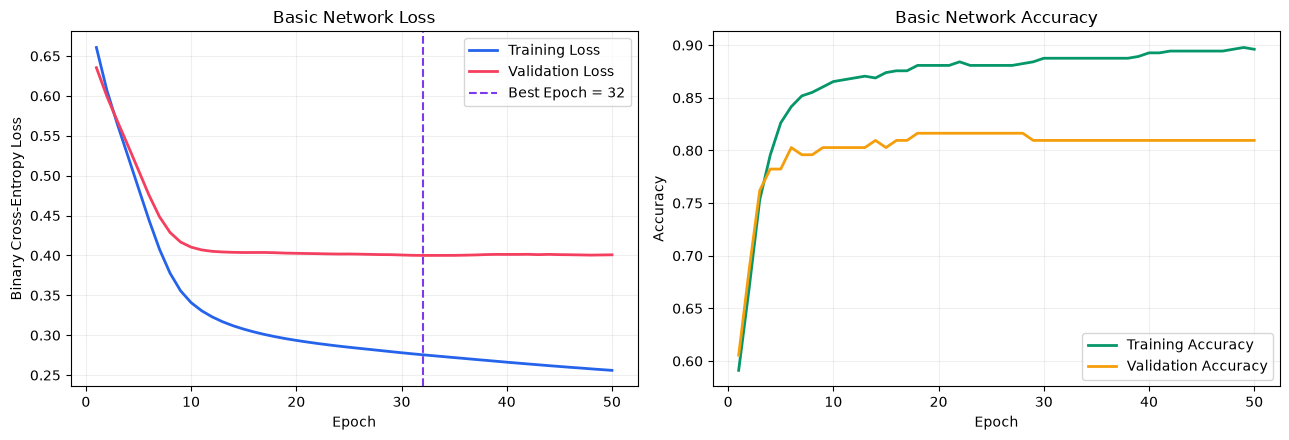

In [8]:
epochs = range(
    1,
    len(history_basic.history["loss"]) + 1
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.5)
)

# Loss curves
axes[0].plot(
    epochs,
    history_basic.history["loss"],
    color="#2563EB",
    linewidth=2,
    label="Training Loss"
)

axes[0].plot(
    epochs,
    history_basic.history["val_loss"],
    color="#F43F5E",
    linewidth=2,
    label="Validation Loss"
)

axes[0].axvline(
    best_basic_epoch,
    color="#7C3AED",
    linestyle="--",
    label=f"Best Epoch = {best_basic_epoch}"
)

axes[0].set_title("Basic Network Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(alpha=0.2)

# Accuracy curves
axes[1].plot(
    epochs,
    history_basic.history["accuracy"],
    color="#059669",
    linewidth=2,
    label="Training Accuracy"
)

axes[1].plot(
    epochs,
    history_basic.history["val_accuracy"],
    color="#F59E0B",
    linewidth=2,
    label="Validation Accuracy"
)

axes[1].set_title("Basic Network Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

<div style="
    background:#FFF1F2;
    border:1px solid #FECDD3;
    border-left:5px solid #F43F5E;
    border-radius:12px;
    padding:16px 19px;
    margin:15px 0 21px 0;
">

<h3 style="color:#BE123C;margin:0 0 9px 0;">
Training Diagnosis
</h3>

<p style="color:#475569;line-height:1.85;margin:0;">
During the early epochs, both training and validation loss decreased,
showing that the network was learning useful patterns.

After approximately 10 epochs, the
<b style="color:#2563EB;">training loss continued decreasing</b>
until it reached 0.256, while the
<b style="color:#DB2777;">validation loss remained near 0.40</b>.

Training accuracy increased to about 89%, while validation accuracy stayed near 81%.
This persistent gap indicates
<b style="color:#BE123C;">moderate overfitting</b>:
the model continued improving on the training records without achieving the same
improvement on unseen validation records.

Epoch 32 produced the lowest validation loss, although the improvement after the
early epochs was very small.
</p>

</div>

<div style="
    background:#F5F3FF;
    border-left:5px solid #8B5CF6;
    border-radius:12px;
    padding:16px 19px;
    margin:20px 0 14px 0;
">

<p style="color:#8B5CF6;font-weight:bold;letter-spacing:1px;margin:0 0 7px 0;">
HANDS-ON LAB · STEP 4
</p>

<h2 style="color:#6D28D9;margin:0 0 9px 0;">
Add Batch Normalization and Dropout
</h2>

<p style="color:#475569;line-height:1.85;margin:0;">
The basic network showed a gap between training and validation performance.

I will add
<b style="color:#2563EB;">Batch Normalization</b>
to stabilize the values moving between layers, and
<b style="color:#DB2777;">Dropout</b>
to reduce the model's dependence on specific neurons.

A dropout rate of
<b style="color:#059669;">0.30</b>
means that 30% of the layer outputs are randomly ignored during each training step.
This is a moderate starting value, not a fixed rule.
</p>

</div>

In [9]:
tf.keras.utils.set_random_seed(42)

regularized_model = Sequential([
    Input(shape=(X_train_processed.shape[1],)),

    Dense(
        16,
        activation="relu",
        name="hidden_layer_1"
    ),

    BatchNormalization(
        name="batch_normalization"
    ),

    Dropout(
        0.30,
        name="dropout_layer"
    ),

    Dense(
        8,
        activation="relu",
        name="hidden_layer_2"
    ),

    Dense(
        1,
        activation="sigmoid",
        name="output_layer"
    )
], name="regularized_heart_network")

regularized_model.summary()

Model: "regularized_heart_network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 16)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 561 (2.19 KB)

 Trainable params: 529 (2.07 KB)

 Non-trainable params: 32 (128.00 B)

<div style="
    background:#ECFDF5;
    border-left:5px solid #10B981;
    border-radius:11px;
    padding:14px 17px;
    margin:14px 0 20px 0;
">

<p style="color:#475569;line-height:1.8;margin:0;">
<b style="color:#047857;">Model Summary:</b>

Batch Normalization increased the total parameters from
<b>497</b> to <b>561</b>.

The model contains <b style="color:#7C3AED;">529 trainable parameters</b>
and <b style="color:#DB2777;">32 non-trainable parameters</b>
used to store the moving mean and variance needed during prediction.
</p>

</div>

In [10]:
regularized_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_regularized = regularized_model.fit(
    X_nn_train,
    y_nn_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=0
)

best_regularized_epoch = (
    np.argmin(history_regularized.history["val_loss"]) + 1
)

print(
    "Best validation-loss epoch:",
    best_regularized_epoch
)
print(
    "Final training loss:",
    round(history_regularized.history["loss"][-1], 4)
)
print(
    "Final validation loss:",
    round(history_regularized.history["val_loss"][-1], 4)
)

Best validation-loss epoch: 48
Final training loss: 0.3029
Final validation loss: 0.4424


<div style="
    background:#FFF7ED;
    border-left:5px solid #F97316;
    border-radius:12px;
    padding:15px 18px;
    margin:20px 0 14px 0;
">

<p style="color:#EA580C;font-weight:bold;letter-spacing:1px;margin:0 0 7px 0;">
STEP 4 CONTINUED
</p>

<h2 style="color:#C2410C;margin:0 0 8px 0;">
Compare the Regularized and Basic Networks
</h2>

<p style="color:#475569;line-height:1.8;margin:0;">
Both networks were trained using the same data, number of epochs,
batch size, optimizer, and learning rate.

Therefore, the following comparison isolates the effect of
<b style="color:#7C3AED;">Batch Normalization and Dropout</b>.
</p>

</div>

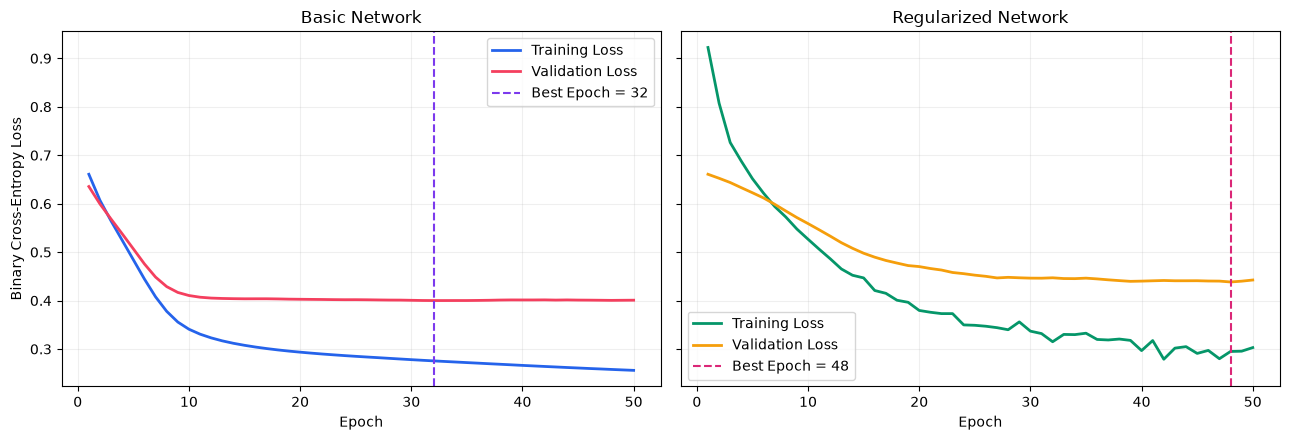

In [11]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.5),
    sharey=True
)

# Basic network
axes[0].plot(
    epochs,
    history_basic.history["loss"],
    color="#2563EB",
    linewidth=2,
    label="Training Loss"
)

axes[0].plot(
    epochs,
    history_basic.history["val_loss"],
    color="#F43F5E",
    linewidth=2,
    label="Validation Loss"
)

axes[0].axvline(
    best_basic_epoch,
    color="#7C3AED",
    linestyle="--",
    label=f"Best Epoch = {best_basic_epoch}"
)

axes[0].set_title("Basic Network")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(alpha=0.2)

# Regularized network
axes[1].plot(
    epochs,
    history_regularized.history["loss"],
    color="#059669",
    linewidth=2,
    label="Training Loss"
)

axes[1].plot(
    epochs,
    history_regularized.history["val_loss"],
    color="#F59E0B",
    linewidth=2,
    label="Validation Loss"
)

axes[1].axvline(
    best_regularized_epoch,
    color="#DB2777",
    linestyle="--",
    label=f"Best Epoch = {best_regularized_epoch}"
)

axes[1].set_title("Regularized Network")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

<div style="
    background:#FFFBEB;
    border:1px solid #FDE68A;
    border-left:5px solid #F59E0B;
    border-radius:12px;
    padding:16px 19px;
    margin:15px 0 21px 0;
">

<h3 style="color:#B45309;margin:0 0 9px 0;">
Regularization Comparison
</h3>

<p style="color:#475569;line-height:1.85;margin:0;">
The regularized network learned more slowly and produced a noisier training curve,
which is expected because Dropout randomly disables neurons during training.

However, its validation loss stabilized near
<b style="color:#DB2777;">0.44</b>,
compared with approximately
<b style="color:#2563EB;">0.40</b>
for the basic network.

Therefore, the selected Batch Normalization and 30% Dropout configuration
reduced the model's ability to fit the training data, but
<b style="color:#BE123C;">did not improve validation generalization</b>.

This demonstrates that regularization is not guaranteed to improve performance;
its strength must match the dataset and model complexity.
</p>

</div>

<div style="
    background:#ECFEFF;
    border-left:5px solid #0891B2;
    border-radius:12px;
    padding:15px 18px;
    margin:20px 0 14px 0;
">

<p style="color:#0891B2;font-weight:bold;letter-spacing:1px;margin:0 0 7px 0;">
HANDS-ON LAB · STEP 5
</p>

<h2 style="color:#0E7490;margin:0 0 8px 0;">
Evaluate on the Test Set and Compare with the Baseline
</h2>

<p style="color:#475569;line-height:1.8;margin:0;">
The test set has remained untouched throughout model development.
I will now compare both neural networks with the
<b style="color:#7C3AED;">Day 1 Logistic Regression baseline</b>
using accuracy, precision, recall, F1-score, and prediction errors.
</p>

</div>

In [12]:
# Generate probabilities
basic_probabilities = basic_model.predict(
    X_test_processed,
    verbose=0
).ravel()

regularized_probabilities = regularized_model.predict(
    X_test_processed,
    verbose=0
).ravel()

# Convert probabilities to classes using 0.50 threshold
basic_predictions = (
    basic_probabilities >= 0.50
).astype(int)

regularized_predictions = (
    regularized_probabilities >= 0.50
).astype(int)

model_comparison = pd.DataFrame([
    {
        "Model": "Day 1 Logistic Regression",
        "Accuracy": 0.886,
        "Precision": 0.886,
        "Recall": 0.912,
        "F1-score": 0.899
    },
    {
        "Model": "Basic Neural Network",
        "Accuracy": accuracy_score(
            y_test_nn,
            basic_predictions
        ),
        "Precision": precision_score(
            y_test_nn,
            basic_predictions
        ),
        "Recall": recall_score(
            y_test_nn,
            basic_predictions
        ),
        "F1-score": f1_score(
            y_test_nn,
            basic_predictions
        )
    },
    {
        "Model": "Regularized Neural Network",
        "Accuracy": accuracy_score(
            y_test_nn,
            regularized_predictions
        ),
        "Precision": precision_score(
            y_test_nn,
            regularized_predictions
        ),
        "Recall": recall_score(
            y_test_nn,
            regularized_predictions
        ),
        "F1-score": f1_score(
            y_test_nn,
            regularized_predictions
        )
    }
])

model_comparison.iloc[:, 1:] = (
    model_comparison.iloc[:, 1:].round(3)
)

model_comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Day 1 Logistic Regression,0.886,0.886,0.912,0.899
1,Basic Neural Network,0.859,0.865,0.882,0.874
2,Regularized Neural Network,0.875,0.925,0.843,0.882


<div style="
    background:#ECFEFF;
    border-left:5px solid #0891B2;
    border-radius:12px;
    padding:16px 19px;
    margin:15px 0 21px 0;
">

<h3 style="color:#0E7490;margin:0 0 9px 0;">
Test-Set Comparison
</h3>

<p style="color:#475569;line-height:1.85;margin:0;">
The Day 1 Logistic Regression remained the strongest overall model,
achieving the highest
<b style="color:#7C3AED;">F1-score of 0.899</b>
and a recall of 0.912.

The regularized network improved over the basic network in accuracy,
precision, and F1-score. Its precision reached
<b style="color:#059669;">0.925</b>,
but its recall decreased to
<b style="color:#BE123C;">0.843</b>.

This means that the regularized network produced fewer false alarms,
but missed more true heart-disease cases.

The experiment shows that a neural network is not automatically better.
For a relatively small, structured tabular dataset,
Logistic Regression can generalize more effectively.
</p>

</div>

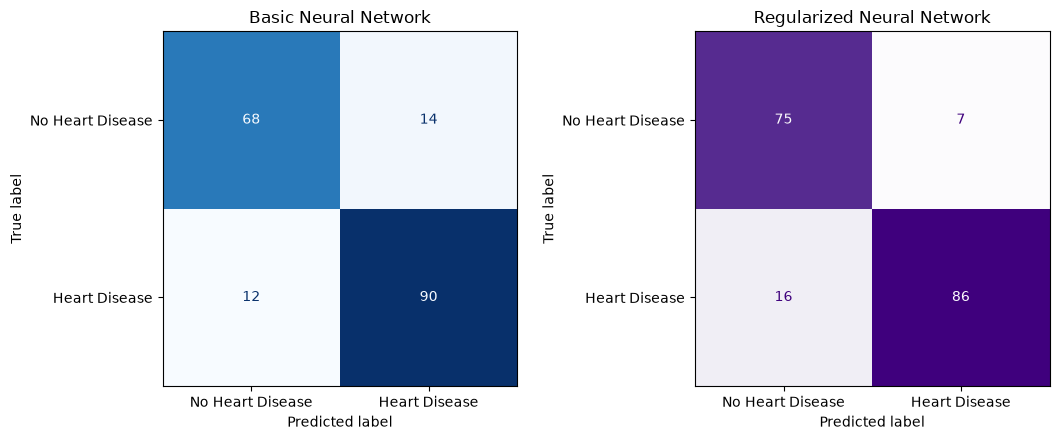

In [13]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.5)
)

ConfusionMatrixDisplay.from_predictions(
    y_test_nn,
    basic_predictions,
    display_labels=[
        "No Heart Disease",
        "Heart Disease"
    ],
    cmap="Blues",
    colorbar=False,
    ax=axes[0]
)

axes[0].set_title(
    "Basic Neural Network"
)

ConfusionMatrixDisplay.from_predictions(
    y_test_nn,
    regularized_predictions,
    display_labels=[
        "No Heart Disease",
        "Heart Disease"
    ],
    cmap="Purples",
    colorbar=False,
    ax=axes[1]
)

axes[1].set_title(
    "Regularized Neural Network"
)

plt.tight_layout()
plt.show()

<div style="
    background:#FFF1F2;
    border-left:5px solid #F43F5E;
    border-radius:12px;
    padding:16px 19px;
    margin:15px 0 21px 0;
">

<h3 style="color:#BE123C;margin:0 0 9px 0;">
Prediction-Error Analysis
</h3>

<p style="color:#475569;line-height:1.85;margin:0;">
The basic network correctly detected 90 heart-disease cases and missed 12,
while producing 14 false-positive predictions.

The regularized network reduced false positives from
<b style="color:#059669;">14 to 7</b>,
which explains its higher precision.

However, its false negatives increased from
<b style="color:#BE123C;">12 to 16</b>,
which reduced recall.

In this project, false negatives are especially important because they represent
patients who have heart disease but are predicted as not having it.
Therefore, the higher precision does not automatically make the regularized network safer.
</p>

</div>

<div style="
    background:#F8FAFC;
    border:1px solid #CBD5E1;
    border-left:5px solid #E11D48;
    border-radius:13px;
    padding:16px 19px;
    margin:20px 0 14px 0;
">

<p style="color:#E11D48;font-weight:bold;letter-spacing:1px;margin:0 0 7px 0;">
RESEARCH EXTENSION · CLINICAL ERROR LENS
</p>

<h2 style="color:#881337;margin:0 0 9px 0;">
Which Errors Did Each Model Trade Away?
</h2>

<p style="color:#475569;line-height:1.8;margin:0;">
A single score can hide the type of mistakes a model makes.
The following chart separates
<b style="color:#7C3AED;">false alarms</b>
from
<b style="color:#BE123C;">missed disease cases</b>,
because these errors do not have the same meaning in a health-risk setting.
</p>

</div>

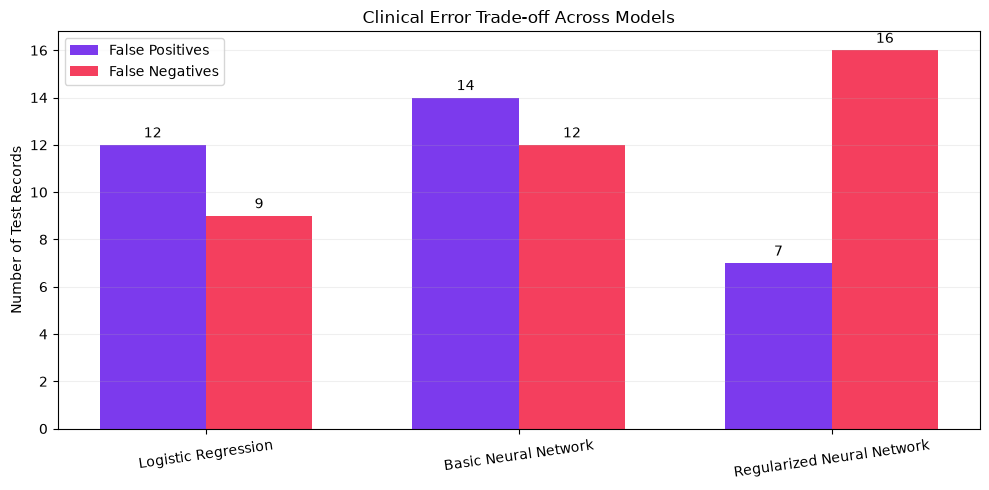

In [14]:
_, basic_false_positives, basic_false_negatives, _ = (
    confusion_matrix(
        y_test_nn,
        basic_predictions
    ).ravel()
)

_, regularized_false_positives, regularized_false_negatives, _ = (
    confusion_matrix(
        y_test_nn,
        regularized_predictions
    ).ravel()
)

error_tradeoff = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Basic Neural Network",
        "Regularized Neural Network"
    ],
    "False Positives": [
        12,
        basic_false_positives,
        regularized_false_positives
    ],
    "False Negatives": [
        9,
        basic_false_negatives,
        regularized_false_negatives
    ]
})

x_positions = np.arange(len(error_tradeoff))
bar_width = 0.34

fig, ax = plt.subplots(figsize=(10, 5))

false_positive_bars = ax.bar(
    x_positions - bar_width / 2,
    error_tradeoff["False Positives"],
    width=bar_width,
    color="#7C3AED",
    label="False Positives"
)

false_negative_bars = ax.bar(
    x_positions + bar_width / 2,
    error_tradeoff["False Negatives"],
    width=bar_width,
    color="#F43F5E",
    label="False Negatives"
)

ax.bar_label(false_positive_bars, padding=3)
ax.bar_label(false_negative_bars, padding=3)

ax.set_title("Clinical Error Trade-off Across Models")
ax.set_ylabel("Number of Test Records")
ax.set_xticks(x_positions)
ax.set_xticklabels(error_tradeoff["Model"], rotation=8)
ax.legend()
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

<div style="
    background:#FFF1F2;
    border-radius:11px;
    padding:14px 17px;
    margin:13px 0 21px 0;
">

<p style="color:#475569;line-height:1.8;margin:0;">
<b style="color:#BE123C;">Research Observation:</b>
The regularized network cut false positives almost in half compared with the basic network,
but it missed the largest number of true disease cases.
Logistic Regression produced the fewest false negatives, which supports its stronger recall.
This view explains why the highest precision does not automatically represent the best project decision.
</p>

</div>

In [15]:
basic_test_loss, basic_test_accuracy = (
    basic_model.evaluate(
        X_test_processed,
        y_test_nn,
        verbose=0
    )
)

regularized_test_loss, regularized_test_accuracy = (
    regularized_model.evaluate(
        X_test_processed,
        y_test_nn,
        verbose=0
    )
)

keras_evaluation = pd.DataFrame({
    "Model": [
        "Basic Neural Network",
        "Regularized Neural Network"
    ],
    "Test Loss": [
        basic_test_loss,
        regularized_test_loss
    ],
    "Test Accuracy": [
        basic_test_accuracy,
        regularized_test_accuracy
    ]
})

keras_evaluation.iloc[:, 1:] = (
    keras_evaluation.iloc[:, 1:].round(3)
)

keras_evaluation

,Model,Test Loss,Test Accuracy
0,Basic Neural Network,0.356,0.859
1,Regularized Neural Network,0.385,0.875


<div style="
    background:#EFF6FF;
    border-left:5px solid #3B82F6;
    border-radius:12px;
    padding:16px 19px;
    margin:15px 0 21px 0;
">

<h3 style="color:#1D4ED8;margin:0 0 9px 0;">
Understanding Test Loss and Accuracy
</h3>

<p style="color:#475569;line-height:1.85;margin:0;">
The basic network achieved a lower test loss of
<b style="color:#2563EB;">0.356</b>,
while the regularized network achieved a higher test accuracy of
<b style="color:#059669;">0.875</b>.

These results are not contradictory.
Accuracy considers only the final class after applying the 0.50 threshold,
while Binary Cross-Entropy also evaluates the quality and confidence of
the predicted probabilities.

Therefore, one model can classify more records correctly while still producing
a higher probability-based loss.
</p>

</div>

<div style="
    background:#F5F3FF;
    border:1px solid #DDD6FE;
    border-radius:14px;
    padding:17px 20px;
    margin:20px 0;
">

<p style="color:#7C3AED;font-weight:bold;letter-spacing:1px;margin:0 0 7px 0;">
NEXT RESEARCH QUESTIONS
</p>

<h2 style="color:#4C1D95;margin:0 0 10px 0;">
What Would I Test Next?
</h2>

<p style="color:#475569;line-height:1.9;margin:0;">
<b style="color:#2563EB;">1 — Early stopping:</b>
restore the weights from the lowest validation-loss epoch instead of keeping the final epoch.<br>
<b style="color:#059669;">2 — Regularization strength:</b>
compare smaller dropout rates such as 0.10 and 0.20 instead of assuming 0.30 is ideal.<br>
<b style="color:#DB2777;">3 — Decision threshold:</b>
select the threshold on validation data according to the cost of false negatives and false positives.<br>
<b style="color:#EA580C;">4 — Stronger evidence:</b>
repeat the experiment across multiple stratified splits and test on a larger external dataset.
</p>

</div>

<div style="
    background:#F8FAFC;
    border:1px solid #DCE5E8;
    border-left:5px solid #2F6F7E;
    border-radius:13px;
    padding:20px 22px;
    margin:24px 0 17px 0;
">

<h2 style="
    color:#16324F;
    margin:0 0 13px 0;
">
Day 4 — Final Conclusion
</h2>

<p style="
    color:#3F4A52;
    line-height:1.9;
    margin:0;
">
The basic neural network learned useful patterns but showed
<b style="color:#9F3A4A;">moderate overfitting</b>.

Adding Batch Normalization and Dropout improved test accuracy from
<b style="color:#2F6F7E;">0.859 to 0.875</b>
and improved F1-score from
<b style="color:#2F6F7E;">0.874 to 0.882</b>.

However, regularization reduced recall from
<b style="color:#9F3A4A;">0.882 to 0.843</b>
and increased false negatives from
<b style="color:#9F3A4A;">12 to 16</b>.

The Day 1 Logistic Regression remained the strongest overall model,
with an F1-score of
<b style="color:#2F6F7E;">0.899</b>
and recall of
<b style="color:#2F6F7E;">0.912</b>.

This experiment demonstrates that a neural network is not automatically
better than a classical model. For this relatively small and structured
tabular dataset, Logistic Regression generalized more effectively.
</p>

</div>

## Hands-On Lab Completion

- [x] **Step 1:** Built a Keras Sequential network for binary classification.
- [x] **Step 2:** Compiled with Adam and Binary Cross-Entropy, then trained for 50 epochs.
- [x] **Step 3:** Plotted training and validation loss and accuracy and diagnosed the fit.
- [x] **Step 4:** Added Batch Normalization and 30% Dropout and compared the loss curves.
- [x] **Step 5:** Evaluated on the held-out test set and compared against the Day 1 baseline.